# Tarea 4

#### Tópicos Selectos De Matemáticas Aplicadas II: Análisis de Datos con Python

Fecha de entrega: Domingo 13 de julio 

Alan Badillo Salas

In [1]:
import numpy
import pandas

import matplotlib.pyplot as pyplot
import seaborn

**1.** Descargue los datos de las **Carpetas de Investigación (acumulado 2016-2024)** en el sitio: https://datos.cdmx.gob.mx/dataset/carpetas-de-investigacion-fgj-de-la-ciudad-de-mexico. Con el parámetro chunksize lea los datos y realice lo siguiente:

* Obtenga un Dataframe con la frecuencia de los delitos en orden descendente y un gráfico que ilustre los primeros 15 delitos con más frecuencia. 

* Obtenga un Dataframe con los delitos cometidos por alcaldía y un gráfico que ilustre esto.

* Obtenga un Dataframe con los delitos cometidos por categoría y un gráfico que ilustre esto.

* ¿Cuales son las 5 colonias donde se han registrado más delitos?

* ¿En que hora se registraron más delitos?

* ¿Cuales son las 3 alcaldias que registraron menos delitos?

**2.** Extraiga las tablas que aparecen en la página web:

https://es.wikipedia.org/wiki/Primera_Divisi%C3%B3n_de_M%C3%A9xico

y realice lo siguiente:

* Obtenga un gráfico de la capacidad de los estadios de la liga mx en orden descendente.

* Obtenga un gráfico de los 10 equipos con más títulos en orden ascendente.

* Obtenga un gráfico de directores técnicos con más títulos en orden ascendente.

* De la tabla de directores técnicos con más títulos conteste lo siguiente: ¿Cuantos de estos directores técnicos conquistaron un título con Guadalajara? ¿Cuantos de estos directores técnicos conquistaron un título con América? (Utilice variables dummy).

In [5]:
tablas = pandas.read_html("https://es.wikipedia.org/wiki/Primera_Divisi%C3%B3n_de_M%C3%A9xico")

In [27]:
estadios = tablas[2].iloc[2:].copy()

estadios.columns = tablas[2].iloc[1]

estadios["Capacidad"] = estadios["Capacidad"].str.replace(r"\D", "", regex=True).astype("Int64")

estadios.sort_values("Capacidad", ascending=False)

1,Equipo,Debut,Presencias,En 1.ª desde,Serie,Estadio,Capacidad
19,Universidad Nacional,1962-63,93,1962-63,93,Olímpico Universitario,73000
5,C. D. Cruz Azul,1964-65,91,1964-65,91,Olímpico Universitario,73000
3,Atlas F. C.,1943-44,109,1979-80,75,Jalisco,55020
10,C. F. Monterrey,1945-46,97,1960-61,95,BBVA,53500
13,Club Puebla,1944-45,92,2007-08,35,Cuauhtémoc,51726
6,C. D. Guadalajara,1943-44,112,1943-44,112,Akron,49850
16,Tigres de la UANL,1974-75,78,1997-98,55,Universitario,41615
2,Club América,1943-44,112,1943-44,112,Ciudad de los Deportes,36681
14,Querétaro F. C.,1990-91,41,2009-10,31,Corregidora,35575
12,C. F. Pachuca,1967-68,63,1998-99,53,Hidalgo,32000


In [28]:
estadios[["Estadio", "Capacidad"]].groupby("Estadio").max().sort_values("Capacidad", ascending=False)

1,Capacidad
Estadio,
Olímpico Universitario,73000
Jalisco,55020
BBVA,53500
Cuauhtémoc,51726
Akron,49850
Universitario,41615
Ciudad de los Deportes,36681
Corregidora,35575
Hidalgo,32000


<Axes: ylabel='Estadio'>

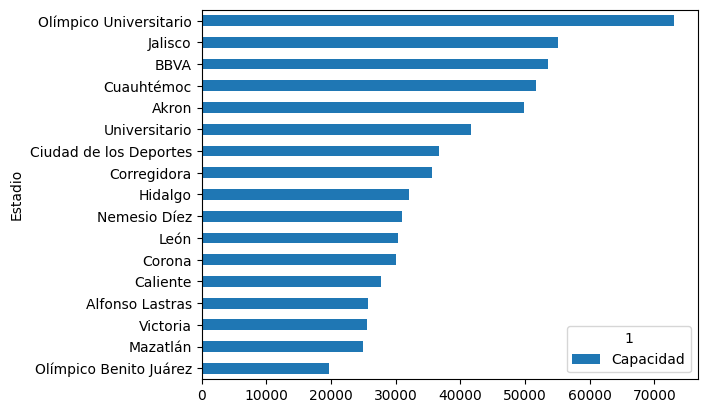

In [32]:
estadios[["Estadio", "Capacidad"]].groupby("Estadio").max().sort_values("Capacidad").plot.barh()

In [36]:
tablas[4]

,Club,Títulos,Subtítulos,Años de los campeonatos,Años subcampeón
0,C. F. América,16,11,"1965-66, 1970-71, 1975-76, 1983-84, 1984-85, P...","1959-60, 1961-62, 1963-64, 1966-67, 1971-72, 1..."
1,C. D. Guadalajara,12,10,"1956-57, 1958-59, 1959-60, 1960-61, 1961-62, 1...","1951-52, 1954-55, 1962-63, 1968-69, M-1970, 19..."
2,Deportivo Toluca F. C.,11,8,"1966-67, 1967-68, 1974-75, V-1998, V-1999, V-2...","1956-57, 1957-58, 1970-71, I-2000, A-2006, A-2..."
3,C. D. Cruz Azul,9,12,"1968-69, M-1970, 1971-72, 1972-73, 1973-74, 19...","1969-70, 1980-81, 1986-87, 1988-89, 1994-95, I..."
4,Club León,8,7,"1947-48, 1948-49, 1951-52, 1955-56, 1991-92, A...","1946-47, 1958-59, 1972-73, 1974-75, I-1997, C-..."
5,C. F. Tigres UANL,8,6,"1977-78, 1981-82, A-2011, A-2015, A-2016, A-20...","1979-80, I-2001, A-2003, A-2014, C-2017 y A-2023"
6,Universidad Nacional,7,8,"1976-77, 1980-81, 1990-91, C-2004, A-2004, C-2...","1967-68, 1977-78, 1978-79, 1984-85, 1987-88, A..."
7,C. F. Pachuca,7,4,"I-1999, I-2001, A-2003, C-2006, C-2007, C-2016...","V-2001, C-2009, C-2014 y C-2022"
8,Santos Laguna,6,6,"I-1996, V-2001, C-2008, C-2012, C-2015 y C-2018","1993-94, V-2000, B-2010, A-2010, A-2011 y G-2021"
9,C. F. Monterrey,5,7,"M-1986, C-2003, A-2009, A-2010 y A-2019","1992-93, A-2004, A-2005, C-2012, C-2016, A-201..."


In [48]:
equipos = tablas[4].copy()

equipos["Títulos"] = equipos["Títulos"].str.replace("-", "0").astype("Int64")

equipos = equipos.sort_values("Títulos", ascending=False).iloc[:10].set_index("Club")

equipos

,Títulos,Subtítulos,Años de los campeonatos,Años subcampeón
Club,,,,
C. F. América,16,11,"1965-66, 1970-71, 1975-76, 1983-84, 1984-85, P...","1959-60, 1961-62, 1963-64, 1966-67, 1971-72, 1..."
C. D. Guadalajara,12,10,"1956-57, 1958-59, 1959-60, 1960-61, 1961-62, 1...","1951-52, 1954-55, 1962-63, 1968-69, M-1970, 19..."
Deportivo Toluca F. C.,11,8,"1966-67, 1967-68, 1974-75, V-1998, V-1999, V-2...","1956-57, 1957-58, 1970-71, I-2000, A-2006, A-2..."
C. D. Cruz Azul,9,12,"1968-69, M-1970, 1971-72, 1972-73, 1973-74, 19...","1969-70, 1980-81, 1986-87, 1988-89, 1994-95, I..."
Club León,8,7,"1947-48, 1948-49, 1951-52, 1955-56, 1991-92, A...","1946-47, 1958-59, 1972-73, 1974-75, I-1997, C-..."
C. F. Tigres UANL,8,6,"1977-78, 1981-82, A-2011, A-2015, A-2016, A-20...","1979-80, I-2001, A-2003, A-2014, C-2017 y A-2023"
Universidad Nacional,7,8,"1976-77, 1980-81, 1990-91, C-2004, A-2004, C-2...","1967-68, 1977-78, 1978-79, 1984-85, 1987-88, A..."
C. F. Pachuca,7,4,"I-1999, I-2001, A-2003, C-2006, C-2007, C-2016...","V-2001, C-2009, C-2014 y C-2022"
Santos Laguna,6,6,"I-1996, V-2001, C-2008, C-2012, C-2015 y C-2018","1993-94, V-2000, B-2010, A-2010, A-2011 y G-2021"


<Axes: ylabel='Club'>

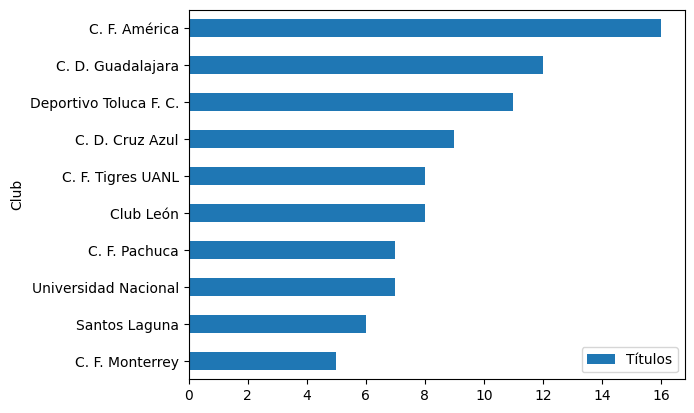

In [49]:
equipos.sort_values("Títulos").plot.barh()

In [67]:
tablas[11]

,N.º,Entrenador,Títulos,Periodo,Equipos,Campeonatos
0,1,Ignacio Trelles,7,1951 - 1991,"Marte (1), Zacatepec (2), Deportivo Toluca (2)...","1953-54, 1954-55, 1957-58, 1966-67, 1967-68, 1..."
1,1,Ricardo Ferretti,7,1991 -,"Guadalajara (1), UNAM (1), Tigres UANL (5)","V1997, C2009, A2011, A2015, A2016, A2017, C2019"
2,3,Raúl Cárdenas,6,1966 - 1998,"Cruz Azul (5), América (1)","1968-69, México 1970, 1971-72, 1972-73, 1973-7..."
3,4,Javier de la Torre,5,1955 - 1984,Guadalajara (5),"1960-61, 1961-62, 1963-64, 1964-65, 1969-70"
4,4,Manuel Lapuente,5,1978 - 2013,"Puebla (2), Necaxa (2), América (1)","1982-83, 1989-90, 1994-95, 1995-96, V2002"
5,4,Víctor Manuel Vucetich,5,1990 -,"León (1), Tecos (1), Pachuca (1), Monterrey (2)","1991-92, 1993-94, A2003, A2009, A2010"
6,7,Enrique Meza,4,1982 -,"Toluca (3), Pachuca (1)","V1998, V1999, V2000, C2007"
7,7,Antonio Mohamed,4,2004 -,"Tijuana (1), América (1), Monterrey (1), Toluc...","A2012, A2014, A2019, C2025"
8,8,Árpád Fekete,3,1957 - 1990,"Guadalajara (2), Club Oro (1)","1958-59, 1959-60, 1962-63"
9,8,José Manuel de la Torre,3,2006 -,"Guadalajara (1), Toluca (2)","A2006, A2008, Bicentenario 2010"


In [71]:
directores = tablas[11].copy()

directores = directores.set_index("Entrenador")

directores.sort_values("Títulos", ascending=False)

,N.º,Títulos,Periodo,Equipos,Campeonatos
Entrenador,,,,,
Ignacio Trelles,1,7,1951 - 1991,"Marte (1), Zacatepec (2), Deportivo Toluca (2)...","1953-54, 1954-55, 1957-58, 1966-67, 1967-68, 1..."
Ricardo Ferretti,1,7,1991 -,"Guadalajara (1), UNAM (1), Tigres UANL (5)","V1997, C2009, A2011, A2015, A2016, A2017, C2019"
Raúl Cárdenas,3,6,1966 - 1998,"Cruz Azul (5), América (1)","1968-69, México 1970, 1971-72, 1972-73, 1973-7..."
Javier de la Torre,4,5,1955 - 1984,Guadalajara (5),"1960-61, 1961-62, 1963-64, 1964-65, 1969-70"
Manuel Lapuente,4,5,1978 - 2013,"Puebla (2), Necaxa (2), América (1)","1982-83, 1989-90, 1994-95, 1995-96, V2002"
Víctor Manuel Vucetich,4,5,1990 -,"León (1), Tecos (1), Pachuca (1), Monterrey (2)","1991-92, 1993-94, A2003, A2009, A2010"
Enrique Meza,7,4,1982 -,"Toluca (3), Pachuca (1)","V1998, V1999, V2000, C2007"
Antonio Mohamed,7,4,2004 -,"Tijuana (1), América (1), Monterrey (1), Toluc...","A2012, A2014, A2019, C2025"
Árpád Fekete,8,3,1957 - 1990,"Guadalajara (2), Club Oro (1)","1958-59, 1959-60, 1962-63"


<Axes: ylabel='Entrenador'>

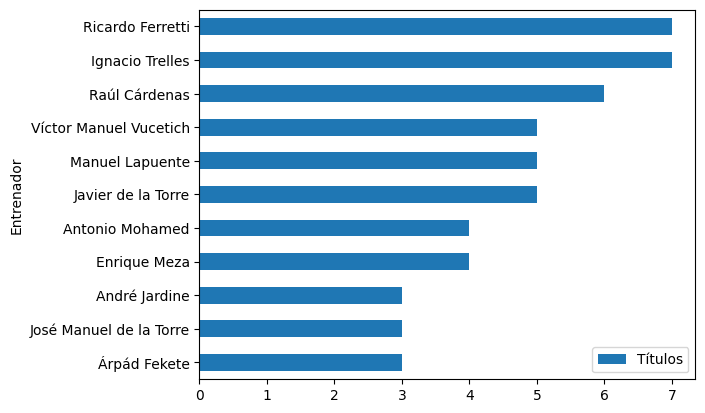

In [74]:
directores[["Títulos"]].sort_values("Títulos").plot.barh()

In [88]:
clubes = []

for row in directores["Equipos"].str.replace(r"\s*\(\d+\)\s*", "", regex=True).str.split(r",\s+"):
    clubes.extend(row)

clubes = set(clubes)

clubes

{'América',
 'Club Oro',
 'Cruz Azul',
 'Deportivo Toluca',
 'Guadalajara',
 'León',
 'Marte',
 'Monterrey',
 'Necaxa',
 'Pachuca',
 'Puebla',
 'Tecos',
 'Tigres UANL',
 'Tijuana',
 'Toluca',
 'UNAM',
 'Zacatepec'}

In [95]:
for club in clubes:
    # print(club, directores["Equipos"].str.match(club))
    directores[f"Club_{club}"] = directores["Equipos"].str.match(club).astype("Int64")

directores

,N.º,Títulos,Periodo,Equipos,Campeonatos,Club_Guadalajara,Club_Zacatepec,Club_Tecos,Club_América,Club_Tigres UANL,...,Club_UNAM,Club_Pachuca,Club_Monterrey,Club_Cruz Azul,Club_Marte,Club_Deportivo Toluca,Club_Toluca,Club_Necaxa,Club_Tijuana,Club_Puebla
Entrenador,,,,,,,,,,,,,,,,,,,,,
Ignacio Trelles,1,7,1951 - 1991,"Marte (1), Zacatepec (2), Deportivo Toluca (2)...","1953-54, 1954-55, 1957-58, 1966-67, 1967-68, 1...",0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
Ricardo Ferretti,1,7,1991 -,"Guadalajara (1), UNAM (1), Tigres UANL (5)","V1997, C2009, A2011, A2015, A2016, A2017, C2019",1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Raúl Cárdenas,3,6,1966 - 1998,"Cruz Azul (5), América (1)","1968-69, México 1970, 1971-72, 1972-73, 1973-7...",0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Javier de la Torre,4,5,1955 - 1984,Guadalajara (5),"1960-61, 1961-62, 1963-64, 1964-65, 1969-70",1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Manuel Lapuente,4,5,1978 - 2013,"Puebla (2), Necaxa (2), América (1)","1982-83, 1989-90, 1994-95, 1995-96, V2002",0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
Víctor Manuel Vucetich,4,5,1990 -,"León (1), Tecos (1), Pachuca (1), Monterrey (2)","1991-92, 1993-94, A2003, A2009, A2010",0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Enrique Meza,7,4,1982 -,"Toluca (3), Pachuca (1)","V1998, V1999, V2000, C2007",0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
Antonio Mohamed,7,4,2004 -,"Tijuana (1), América (1), Monterrey (1), Toluc...","A2012, A2014, A2019, C2025",0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
Árpád Fekete,8,3,1957 - 1990,"Guadalajara (2), Club Oro (1)","1958-59, 1959-60, 1962-63",1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [96]:
directores[["Club_Guadalajara", "Club_América"]]

,Club_Guadalajara,Club_América
Entrenador,,
Ignacio Trelles,0,0
Ricardo Ferretti,1,0
Raúl Cárdenas,0,0
Javier de la Torre,1,0
Manuel Lapuente,0,0
Víctor Manuel Vucetich,0,0
Enrique Meza,0,0
Antonio Mohamed,0,0
Árpád Fekete,1,0


In [97]:
directores[["Club_Guadalajara", "Club_América"]].sum()

Club_Guadalajara    4
Club_América        1
dtype: Int64

Cuatro directores conquistaron al menos un título con el Guadalajara y solo uno con el América (André Jardine).

**3.** Cargue los datos de los ingresos de la Ciudad de México en el año 2021 (**ingresos_CDMX_2021.csv** en GitHub) y realice lo siguiente:

* Elimine la cadena "desc_" en cada columna que la contenga.

* Limpie las cadenas de caracteres contenidas en las columnas
(esto es, elimine caracteres como Û, ¢, °, Ì, etc.)

* La única variable numérica debe ser la variable "monto_recaudado".

* Obtenga un Dataframe que describa el monto recaudado en cada rubro. Obtenga una gráfica que ilustre esto.

* Obtenga un Dataframe que describa el monto recaudado en cada rubro y el tipo de rubro.

* Obtenga un Dataframe que describa el monto recaudado en cada trimestre.  Obtenga una gráfica que ilustre esto.

* Obtenga un Dataframe que describa el monto recaudado en cada rubro en los tres trimestres.  Obtenga una gráfica que ilustre esto.

* Coloque en orden alfabético el Dataframe anterior de acuerdo al rubro (1er índice).

* ¿Cuál fue el monto total recaudado por la CDMX en 2021?

* ¿De cuánto fue el endeudamiento interno?

**4.** Una empresa realiza entrevistas a 20 candidatos para un puesto.
De esos 20 candidatos, 14 son mujeres y 6 son hombres.

Al final del proceso, se seleccionan 8 personas, de las cuales 7 son mujeres.

Un analista externo se pregunta si el proceso de selección favoreció a las mujeres.
Instrucciones:

- Plantea una prueba de hipótesis para evaluar si hubo favoritismo hacia las mujeres.
    - Define la hipótesis nula: la selección fue aleatoria (sin favoritismo).
    - Define la hipótesis alternativa: hay favoritismo hacia las mujeres.

- Simula mediante Monte Carlo el proceso de seleccionar 8 personas al azar de los 20 candidatos, repitiendo esto al menos 100,000 veces.

- Calcula el p-valor como la proporción de simulaciones en las que 7 o más mujeres fueron seleccionadas.

- Concluye si hay evidencia suficiente para pensar que el proceso favoreció a las mujeres. Usa un nivel de significancia de 5 %.

**5.** Cargue en un objeto 'defunciones' las columnas 'edad', 'sexo','estado' y 'alcaldia' de los datos de las actas de defunción de la Ciudad de México (**defunciones_CDMX.csv** en GitHub) y realice lo siguiente:

* Agrupe en edades de 10 años: (0, 10], (10, 20], ... y calcule la frecuencia de defunciones en estos grupos (usar pandas.cut).

* Añada a defunciones una columna con el grupo etario de cada persona:

    Niñez (de 0 a 11 años)
    
    Adolescencia (de 12 a 18 años)
    
    Juventud (de 19 a 30 años)
    
    Adultez (de 31 a 59 años)
    
    Vejez (de 60 años en adelante)
    

* Obtenga un Dataframe que contenga la cantidad de defunciones por grupo etario e ilustre con una gráfica.
